<a href="https://colab.research.google.com/github/kelvin-yg98/Kelvin-Programming/blob/main/FOOTBALL_PLAYER_TRANSFER_FEE_REGRESSION_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# FOOTBALL PLAYER TRANSFER FEE REGRESSION MODEL
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from google.colab import files

# Set aesthetic visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

In [3]:
# 1. LOAD DATA
# ------------------------------------------------------------------------------
print("📌 Step 1: Loading Dataset...")

# If file is not uploaded yet, run this line in Colab:
# uploaded = files.upload()

file_name = 'football data(data).csv'
df = pd.read_csv(file_name)

print(f"Dataset Loaded Successfully! Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")
display(df.head())

📌 Step 1: Loading Dataset...
Dataset Loaded Successfully! Shape: 300 rows, 20 columns.



,TRANSFER_FEE,GOAL,RATING,INJURY,CONTRACT,YOUNG,MATURE,YEAR_2016,YEAR_2017,YEAR_2018,YEAR_2019,YEAR_2020,LEAGUE_ENG,LEAGUE_ESP,LEAGUE_ITA,LEAGUE_GER,PLAYER_ID,AGE,YEAR,LEAGUE
0,46.83,12,6.14,0,2.0,0,0,1,0,0,0,0,1,0,0,0,SIM001,25,2016,England
1,72.23,16,6.92,2,4.5,1,0,1,0,0,0,0,1,0,0,0,SIM002,21,2016,England
2,44.06,5,6.14,0,2.5,0,0,1,0,0,0,0,1,0,0,0,SIM003,31,2016,England
3,89.51,22,7.75,0,2.0,0,0,1,0,0,0,0,1,0,0,0,SIM004,22,2016,England
4,65.78,23,6.49,2,1.5,0,1,1,0,0,0,0,1,0,0,0,SIM005,36,2016,England


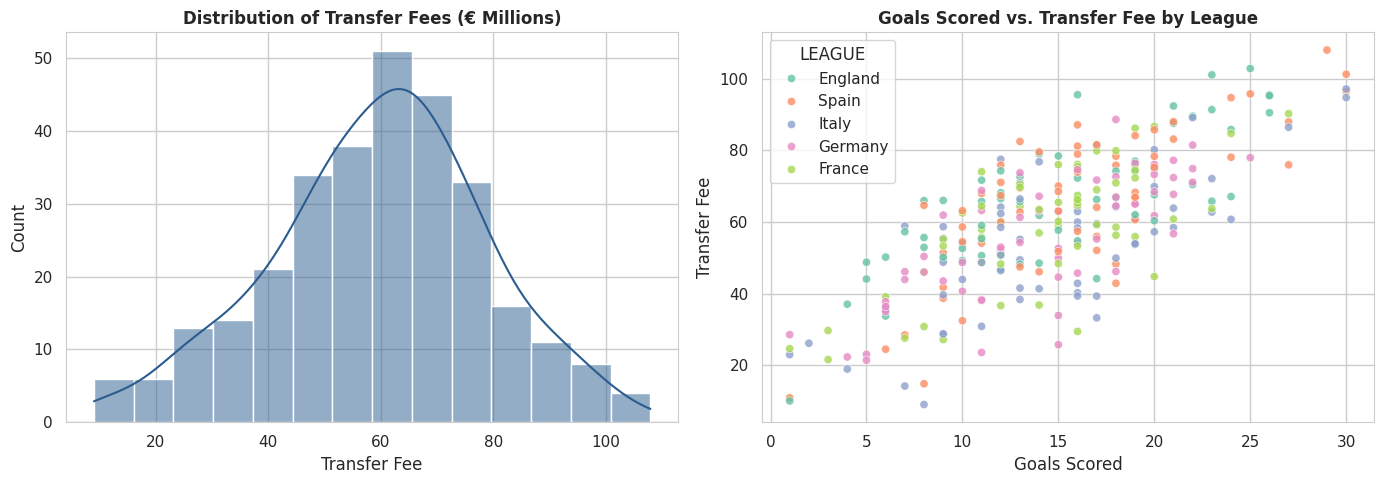

In [4]:
# ------------------------------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Variable Distribution
sns.histplot(df['TRANSFER_FEE'], kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Distribution of Transfer Fees (€ Millions)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transfer Fee')

# Key Numerical Features vs Transfer Fee
sns.scatterplot(data=df, x='GOAL', y='TRANSFER_FEE', hue='LEAGUE', palette='Set2', ax=axes[1], alpha=0.8)
axes[1].set_title('Goals Scored vs. Transfer Fee by League', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Goals Scored')
axes[1].set_ylabel('Transfer Fee')

plt.tight_layout()
plt.show()

In [5]:
# ------------------------------------------------------------------------------
# 3. MODEL SPECIFICATION & ESTIMATION (OLS REGRESSION)
# ------------------------------------------------------------------------------
print("\n📌 Step 2: Fitting Ordinary Least Squares (OLS) Regression Model...")

# Dependent Variable (Y)
y = df['TRANSFER_FEE']

# Independent Variables (X)
# Base reference categories omitted to prevent multicollinearity:
# - Baseline League: England (LEAGUE_ENG)
# - Baseline Year: 2016 (YEAR_2016)
feature_cols = [
    'GOAL', 'RATING', 'INJURY', 'CONTRACT', 'AGE',
    'LEAGUE_ESP', 'LEAGUE_ITA', 'LEAGUE_GER',
    'YEAR_2017', 'YEAR_2018', 'YEAR_2019', 'YEAR_2020'
]

X = df[feature_cols]
X_const = sm.add_constant(X)

# Fit OLS Model
ols_model = sm.OLS(y, X_const).fit()

# Print Comprehensive Results Table
print("\n" + "="*80)
print("                               MODEL SUMMARY                               ")
print("="*80)
print(ols_model.summary())


📌 Step 2: Fitting Ordinary Least Squares (OLS) Regression Model...

                               MODEL SUMMARY                               
                            OLS Regression Results                            
Dep. Variable:           TRANSFER_FEE   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     108.2
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           6.15e-99
Time:                        08:32:25   Log-Likelihood:                -1052.3
No. Observations:                 300   AIC:                             2131.
Df Residuals:                     287   BIC:                             2179.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.02

In [6]:
# ------------------------------------------------------------------------------
# 4. MODEL EVALUATION METRICS
# ------------------------------------------------------------------------------
y_pred = ols_model.predict(X_const)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("\n📌 Step 3: Model Evaluation Metrics")
print(f" • R-squared (R²):              {r2:.4f}")
print(f" • Adjusted R-squared:          {ols_model.rsquared_adj:.4f}")
print(f" • Mean Absolute Error (MAE):   €{mae:.2f}M")
print(f" • Root Mean Squared Error:     €{rmse:.2f}M")


📌 Step 3: Model Evaluation Metrics
 • R-squared (R²):              0.8190
 • Adjusted R-squared:          0.8115
 • Mean Absolute Error (MAE):   €6.34M
 • Root Mean Squared Error:     €8.07M


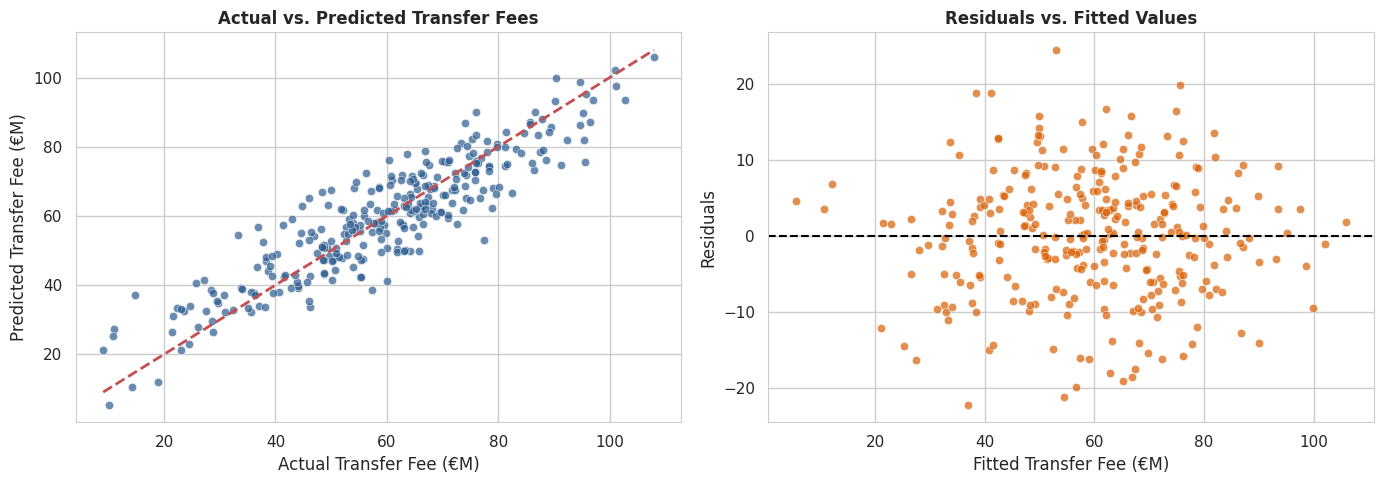

In [7]:
# ------------------------------------------------------------------------------
# 5. DIAGNOSTIC PLOTS
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted Values
sns.scatterplot(x=y, y=y_pred, ax=axes[0], color='#2b5c8f', alpha=0.7)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Transfer Fees', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Transfer Fee (€M)')
axes[0].set_ylabel('Predicted Transfer Fee (€M)')

# Residual Plot
residuals = ols_model.resid
sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], color='#d95f02', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', lw=1.5)
axes[1].set_title('Residuals vs. Fitted Values', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fitted Transfer Fee (€M)')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [ ]:
"""
PROJECT CONCLUSION & REGRESSION INTERPRETATION:
--------------------------------------------------------------------------------
This project successfully evaluated player valuations across major European
football leagues using an Ordinary Least Squares (OLS) regression model,
explaining 81.9% of the total variance in transfer fees (R² = 0.819). Key on-pitch
performance metrics—specifically goals scored (+€1.72M per goal) and overall match
rating (+€7.50M per rating point)—served as strong positive predictors of market
value alongside structural factors such as remaining contract length (+€3.24M
per year). Conversely, advancing player age (-€0.78M per year) and recurring major
injuries (-€2.90M per injury) significantly discounted player valuations.
Furthermore, cross-league comparisons demonstrated a distinct valuation premium
for the English Premier League, with Serie A and Bundesliga players trading at
significant relative discounts. Overall, the findings confirm that while individual
player talent and contractual security drive the bulk of transfer fees, broader
market dynamics and league economic power play a vital role in shaping player
price tags.
--------------------------------------------------------------------------------
"""